In [1]:
import psycopg2
import pandas as pd


In [2]:
geo = pd.read_csv('geolocation.csv')


customer = pd.read_csv('customer.csv')


order = pd.read_csv('orders.csv')


orderitem = pd.read_csv('order_items.csv')


payment = pd.read_csv('payments.csv')


product = pd.read_csv('product_category.csv')


prod = pd.read_csv('products.csv')


review = pd.read_csv('reviews.csv')

seller = pd.read_csv('sellers.csv')


In [9]:
# 1  top locations by purchase volume

result = (
    pd.merge(order, customer, on='customer_id')
      .groupby('customer_state')['order_id']
      .count()
      .reset_index(name='total_orders')
      .sort_values('total_orders', ascending=False)
)
display(result)


,customer_state,total_orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [5]:
# 2  count of unique customer_id with more than one order_id
result=(
    order.groupby('customer_id')['order_id']
    .count()
    .reset_index(name='order_count')
    .query('order_count >1')
)
print(result)

Empty DataFrame
Columns: [customer_id, order_count]
Index: []


In [8]:
# 3  customer lifetime value
result=(
    pd.merge(order,payment,on= 'order_id')
    .groupby('customer_id')['payment_value']
    .sum()
    .reset_index(name='lifetime_value')
    .sort_values('lifetime_value',ascending= False)
    )
display(result)

,customer_id,lifetime_value
8546,1617b1357756262bfa56ab541c47bc16,13664.08
91984,ec5b2ba62e574342386871631fafd3fc,7274.88
77521,c6e2731c5b391845f6800c97401a43a9,6929.31
95123,f48d464a0baaea338cb25f816991ab1f,6922.21
24771,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66
...,...,...
9456,184e8e8e48937145eb96c721ef1f0747,10.07
65094,a790343ca6f3fee08112d678b43aa7c5,9.59
64966,a73c1f73f5772cf801434bf984b0b1a7,0.00
20653,3532ba38a3fd242259a514ac2b6ae6b6,0.00


In [7]:
# 4  delivery delays
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date']= pd.to_datetime(order['order_estimated_delivery_date'])
orders_clean = order.dropna(subset=['order_delivered_customer_date','order_estimated_delivery_date'])
delayed_orders = orders_clean[orders_clean['order_delivered_customer_date']>orders_clean['order_estimated_delivery_date']].copy()
delayed_orders['delay_dates'] = delayed_orders['order_delivered_customer_date'] - delayed_orders['order_estimated_delivery_date']
delayed_orders_sorted = delayed_orders.sort_values(by= 'delay_dates' ,ascending=False)
result = delayed_orders_sorted[['order_id','delay_dates']]
display(result)

,order_id,delay_dates
55619,1b3190b2dfa9d789e1f14c05b647a14a,188 days 23:24:07
19590,ca07593549f1816d26a572e06dc1eab6,181 days 14:36:39
11399,47b40429ed8cce3aee9199792275433f,175 days 20:51:31
81401,2fe324febf907e3ea3f2aa9650869fa5,167 days 17:00:07
89130,285ab9426d6982034523a855f55a885e,166 days 14:00:04
...,...,...
34736,308163f9666c3f335e92b0f0f61554ed,0 days 00:05:14
47556,5989369fa081195d8762312fad7d588d,0 days 00:05:10
57100,c1ecc15bc30548ecad160437f07df801,0 days 00:04:16
57212,0eae0847dbceff8611d706710c724ee2,0 days 00:04:03


In [10]:
# 5 time taken from order_approved_at to order_delivered_customer_date
merged_df = pd.merge(orderitem, seller, on='seller_id')
result = merged_df.groupby('seller_state').agg(
    avg_freight = ('freight_value','mean'),
    total_items = ('order_id','count')
).reset_index()

result = result.sort_values(by ='avg_freight',ascending = False)
result

,seller_state,avg_freight,total_items
18,RO,50.912857,14
3,CE,46.381170,94
12,PB,39.188158,38
14,PI,36.943333,12
0,AC,32.840000,1
5,ES,32.718091,372
10,MT,31.942966,145
21,SE,31.849000,10
2,BA,30.638694,643
7,MA,29.978494,405


In [11]:
# 6 From order_items, analyze freight_value across regions or sellers.
merged_df = pd.merge(orderitem, seller, on='seller_id')
result = merged_df.groupby('seller_state').agg(
    avg_freight = ('freight_value','mean'),
    total_items = ('order_id','count')
).reset_index()

result = result.sort_values(by ='avg_freight',ascending = False)
result

,seller_state,avg_freight,total_items
18,RO,50.912857,14
3,CE,46.381170,94
12,PB,39.188158,38
14,PI,36.943333,12
0,AC,32.840000,1
5,ES,32.718091,372
10,MT,31.942966,145
21,SE,31.849000,10
2,BA,30.638694,643
7,MA,29.978494,405


In [13]:
# 7 Product Weight vs Shipping Cost
merged_df = pd.merge(prod,orderitem,on = 'product_id')
#filter null rows
# filtered_df = merged_df.dropna(subset=['product_weight_g', 'freight_value'])
result = merged_df.groupby('product_id').agg(
    avg_weight = ('product_weight_g','mean'),
    avg_freight = ('freight_value','mean'),
    total = ('order_id','count')
).reset_index()

result = result.sort_values(by='avg_freight',ascending=False)
# result = result.sort_values(by=['avg_freight','avg_weight'],ascending=[False,False])

result

,product_id,avg_weight,avg_freight,total
30404,ec31d2a17b299511e7c8627be9337b9b,14675.0,409.680000,1
4951,256a9c364b75753b97bee410c9491ad8,25250.0,339.590000,1
16354,7e53e051875b2a0c9f22acd8a9a29a20,11300.0,317.470000,1
21032,a3cd9517ebf5a50dca25acce54f3b171,30000.0,308.336667,3
7557,3a1855685a49813f60e6193864f7215e,11450.0,306.060000,1
...,...,...,...,...
26033,ca165220cdeb3367ea870193baf4a7cd,1600.0,0.030000,1
21770,aa0568a1b7093748a1922993f5817983,200.0,0.030000,3
24030,baf59a3a8f15ea34f04394f44bad573a,450.0,0.020000,1
2335,11b906b2a09fb80668f4478dd3f9c324,750.0,0.020000,1


In [16]:
# 8 Popular Payment Methods From payments, count of orders by payment_type
result = payment.groupby('payment_type').agg(
    total = ('order_id','count')
).reset_index()
result =result.sort_values(by='total',ascending=False)
result

# when you want to print specific cols
# print(result[['payment_type', 'avg_payment']])

,payment_type,total
1,credit_card,76795
0,boleto,19784
4,voucher,5775
2,debit_card,1529
3,not_defined,3


In [17]:
# 9 Installment Trends Analyze average payment_installments by product category or price range.

merged_1 = pd.merge(orderitem,prod,on='product_id')
merged_df = pd.merge(merged_1,payment,on='order_id')
filtered_df = merged_df.dropna(subset=['payment_installments'])
result = filtered_df.groupby('product_category_name').agg(
    avg_installment = ('payment_installments','mean'),
    total_orders = ('order_id','count')
)

result =result.sort_values(by='total_orders',ascending=False)
result


,avg_installment,total_orders
product_category_name,,
cama_mesa_banho,3.553159,11823
beleza_saude,3.020658,9972
esporte_lazer,2.505198,8945
moveis_decoracao,3.120654,8744
informatica_acessorios,2.253898,8082
...,...,...
portateis_cozinha_e_preparadores_de_alimentos,2.000000,15
cds_dvds_musicais,2.571429,14
pc_gamer,2.500000,10


In [20]:
# 10 Revenue Trends Sum payment_value by month using order_purchase_timestamp.
merged_df = pd.merge(payment, order, on='order_id')
filtered_df = merged_df.dropna(subset=['order_purchase_timestamp'])

# Convert timestamp to month format (YYYY-MM)
filtered_df['month'] = pd.to_datetime(filtered_df['order_purchase_timestamp']).dt.to_period('M').astype(str)
result = filtered_df.groupby('month').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'count')  
).reset_index()

result = result.sort_values('month')
result
# print(result.to_html())

,month,total_revenue,total_orders
0,2016-09,252.24,3
1,2016-10,59090.48,342
2,2016-12,19.62,1
3,2017-01,138488.04,850
4,2017-02,291908.01,1886
5,2017-03,449863.60,2837
6,2017-04,417788.03,2571
7,2017-05,592918.82,3944
8,2017-06,511276.38,3436
9,2017-07,592382.92,4317


In [21]:
# 11 Top-Selling Products / Categories
merged_df = pd.merge(prod,orderitem,on='product_id')
result = merged_df.groupby('product_category_name').agg(
    total_items = ('product_id','count')
).reset_index()

result = result.sort_values(by='total_items',ascending=False)
result

,product_category_name,total_items
13,cama_mesa_banho,11115
11,beleza_saude,9670
32,esporte_lazer,8641
54,moveis_decoracao,8334
44,informatica_acessorios,7827
...,...,...
17,cds_dvds_musicais,14
46,la_cuisine,14
60,pc_gamer,9
37,fashion_roupa_infanto_juvenil,8


In [22]:
# 12 Product Rating Distribution 
merged_df = pd.merge(review,orderitem,on='order_id')
result = merged_df.groupby('product_id').agg(
    total_reviews = ('review_id','count'),
    average_score = ('review_score','mean')
).reset_index()
result =result.sort_values(by='average_score',ascending=False)
result

,product_id,total_reviews,average_score
0,00066f42aeeb9f3007548bb9d3f33c38,1,5.0
12389,60314cbf527af04ebc935be7c02dc1cd,1,5.0
12345,5fe23e6307c231e287f13c0a4be06c88,1,5.0
12346,5fe490e61e7a37f2f0d1ad1771ac027d,3,5.0
25417,c696cd2db7870be08c37822f7c0ef831,1,5.0
...,...,...,...
6656,336b5407e252cac6f4e4270979cec8ad,1,1.0
17220,86304b9e4529f2686bc91f37c6392801,1,1.0
28803,e09cef1f7f2bc3a9c9d996608944de19,1,1.0
22569,b0b727747746e677a470d0948bb68520,1,1.0


In [23]:
# 13 Return / Low Score Products

merged_df= pd.merge(orderitem,review,on='order_id')
filtered_df = merged_df.query('review_score <=2')
result = filtered_df.groupby('product_id').agg(
    total_low_score_reviews = ('review_score','count')
)
result = result.sort_values(by='total_low_score_reviews',ascending=False)
result

,total_low_score_reviews
product_id,
422879e10f46682990de24d770e7f83d,95
99a4788cb24856965c36a24e339b6058,80
53759a2ecddad2bb87a079a1f1519f73,77
368c6c730842d78016ad823897a372db,75
aca2eb7d00ea1a7b8ebd4e68314663af,74
...,...
668b1e2b9471f837ba1797832e3f2012,1
665dcf48bfab7017f4ac917abaafac4f,1
6642e66f26b6e23817ada36eeae229bc,1


In [24]:
# 14 Top Sellers by Revenue 
result = orderitem.groupby('seller_id').agg(
    total_order_items = ('order_item_id','count'),
    total_revenue = ('price','sum')
).reset_index()
result = result.sort_values('total_revenue',ascending=False)
result

,seller_id,total_order_items,total_revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63
1013,53243585a1d6dc2643021fd1853d8905,410,222776.05
881,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
...,...,...,...
627,34aefe746cd81b7f3b23253ea28bef39,1,8.00
1370,702835e4b785b67a084280efca355756,1,7.60
373,1fa2d3def6adfa70e58c276bb64fe5bb,1,6.90
1465,77128dec4bec4878c37ab7d6169d6f26,1,6.50


In [ ]:
# 15 Seller Locations vs Shipping Costs 
merged_df = pd.merge(seller,orderitem,on='seller_id')
result = merged_df.groupby('seller_state').agg(
    average_freight_value = ('freight_value','mean'),
    total_orders = ('order_item_id','count')
).reset_index()
result = result.sort_values(by='average_freight_value',ascending=False)

result

,seller_state,average_freight_value,total_orders
18,RO,50.912857,14
3,CE,46.381170,94
12,PB,39.188158,38
14,PI,36.943333,12
0,AC,32.840000,1
5,ES,32.718091,372
10,MT,31.942966,145
21,SE,31.849000,10
2,BA,30.638694,643
7,MA,29.978494,405


In [26]:
# 16 Order Fulfillment Time

order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
orderitem['shipping_limit_date']= pd.to_datetime(orderitem['shipping_limit_date'])
merged_df = pd.merge(orderitem,order,on='order_id')
filtered_df = merged_df.dropna(subset=['order_delivered_carrier_date','shipping_limit_date'])
final_df = filtered_df.query('order_delivered_carrier_date > shipping_limit_date')
final_df['fulfillment_days'] = final_df['order_delivered_carrier_date'] - final_df['shipping_limit_date']
result = final_df.sort_values(by='fulfillment_days',ascending=False)
result[['order_id','fulfillment_days']]

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_38632\3183162981.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['fulfillment_days'] = final_df['order_delivered_carrier_date'] - final_df['shipping_limit_date']


,order_id,fulfillment_days
96290,da81fbc27b55e0f3d2813cf2078dc780,116 days 18:18:06
61203,8b7fd198ad184563c231653673e75a7f,95 days 08:40:15
66484,97f48024fcc76f1898e397ad6966e3a0,91 days 01:16:38
58991,866314550f6d7a55c82917d9b4463e1f,59 days 13:41:36
58992,866314550f6d7a55c82917d9b4463e1f,59 days 13:41:36
...,...,...
75481,abe45c6183ce8438e33286caf45374b4,0 days 00:00:08
109234,f83bde2f77db7c7343f2bd54bb17fda3,0 days 00:00:07
48571,6e5fe7366a2e1bfbf3257dba0af1267f,0 days 00:00:01
48567,6e5fe7366a2e1bfbf3257dba0af1267f,0 days 00:00:01


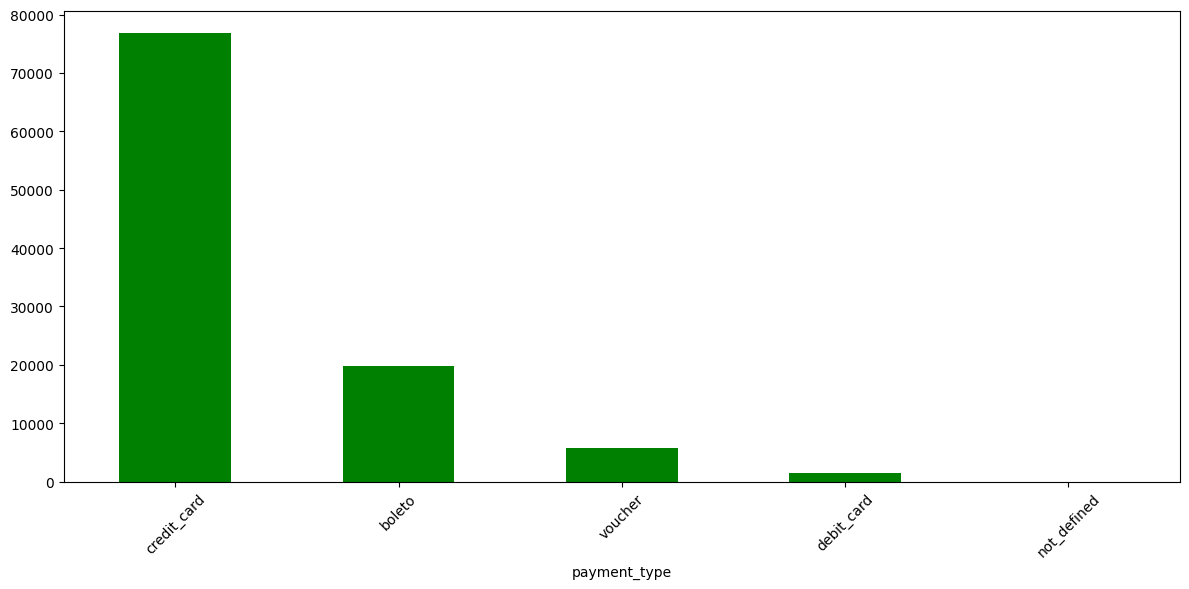

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

payment = pd.read_csv('payments.csv')
payment_count = payment.payment_type.value_counts()

plt.figure(figsize=(12, 6))
payment_count.plot (kind='bar', color='green')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

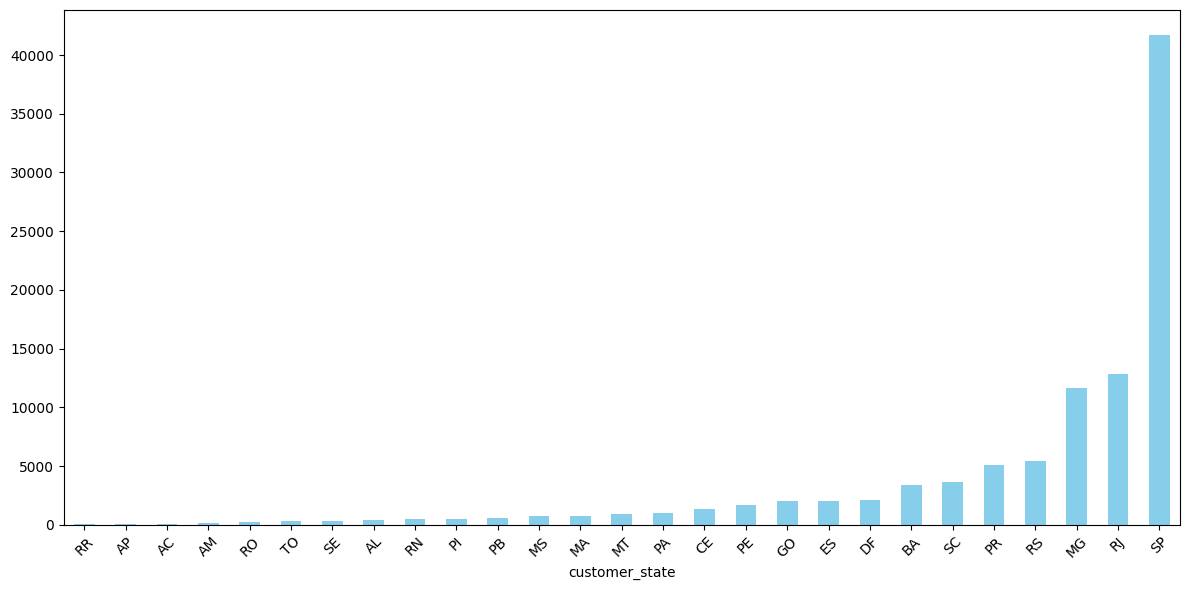

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

customer = pd.read_csv('customer.csv')
state_counts = customer.customer_state.value_counts().sort_values(ascending=True)
# state_counts = customer.groupby('customer_state').customer_state.value_counts()[::-1]

plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar', color='skyblue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
